# 18.13 圖片／音訊能力能如何蒸餾？


教師看圖時用16個視覺token，學生只用4個，回答三個文字token。若把兩條整段logits直接對上，同一列可能一邊仍在處理圖片、另一邊已經在回答，機率就不具相同意義。我們希望比較相同答案A0、A1、A2的分布；[模態展開](https://birdhackor.github.io/tiny-perceptron-vlm/10.7.html)改變前文位置，必須按[下一字預測的位移](https://birdhackor.github.io/tiny-perceptron-vlm/7.4.html)各自找到負責同一答案的列。

用沒有角色或問題額外位置的玩具序列，教師前文16格、學生4格，答案為A0、A1、A2。A0輸入位置分別16與4，但預測A0的logits來自它前一格，也就是15與3；A1由16與4預測，A2由17與5預測。這個向左一格的對齊非常重要，不能因只在說圖片就忘記下一字預測的規則。

圖中每一個答案框都配兩邊負責預測它的位置。A0對教師15、學生3，A1對16、4，A2對17、5；這是在配同一個待預測答案，不是配相同絕對索引。答案輸入本身從教師16／學生4開始，和負責預測A0的前一格分開。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

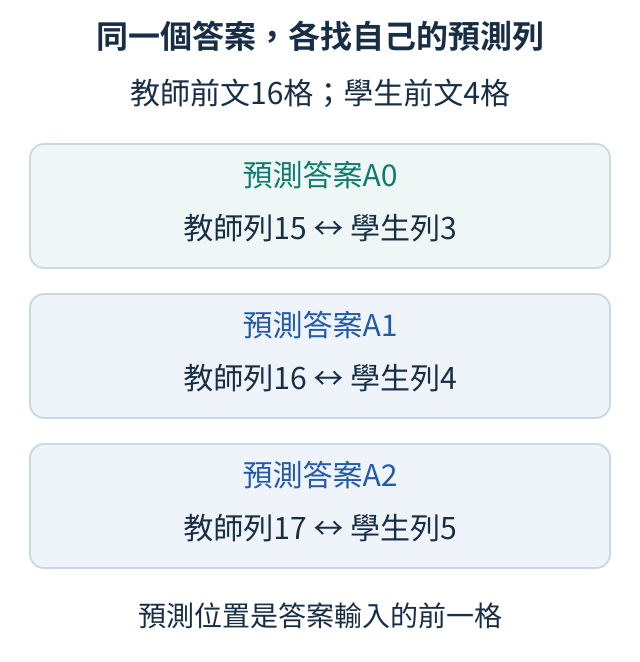

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-18-modal-answer-rows.svg")))

In [3]:
import torch
from tiny_perceptron.alignment import distillation_kl

teacher_prefix, student_prefix, answer_tokens = 16, 4, 3
t_rows = list(range(teacher_prefix - 1, teacher_prefix + answer_tokens - 1))
s_rows = list(range(student_prefix - 1, student_prefix + answer_tokens - 1))
t_logits = torch.zeros(1, teacher_prefix + answer_tokens, 2)
s_logits = torch.zeros(1, student_prefix + answer_tokens, 2)
t_logits[:, t_rows] = torch.tensor([0.8, 0.2]).log()
t_answer, s_answer = t_logits[:, t_rows], s_logits[:, s_rows]
labels = torch.zeros(1, answer_tokens, dtype=torch.long)
print("預測位置", t_rows, s_rows)
print("對齊形狀", tuple(t_answer.shape), tuple(s_answer.shape))
print("答案KL", round(distillation_kl(s_answer, t_answer, labels, temperature=1).item(), 4))

預測位置 [15, 16, 17] [3, 4, 5]
對齊形狀 (1, 3, 2) (1, 3, 2)
答案KL 0.1927


輸入只是人工分數表，沒有載入圖片或聲音。教師選中三格都設比例 `[0.8,0.2]`，學生零分數則均勻；`t_rows`和`s_rows`各自挑出預測相同答案的logits，labels將三格都標成有效。應印出 `[15,16,17]`與 `[3,4,5]`，兩邊形狀同為 `(1,3,2)`，KL0.1927。未對齊時整段長度19與7不同，不能直接按列做分布誤差。

真實模型還含角色、問題、圖像標記或音訊框，答案位置應從展開後的有效labels與預測位移推導，不能固定套16和4。兩邊也需看同一份圖片/聲音與問題，否則學生是在學另一個條件下的教師回答。若比較內部視覺特徵，因數量與維度不同，還需另外設計映射與目標，不是直接複用這個文字KL。

同一答案對齊後，仍要用真實輸入驗收學生。一個合成圖片加純音調的實測例子裡，加入教師分布的學生在正常圖片與空白圖片下，十二串生成ID完全相同，且所有形狀都回答`circle`；這批輸入的音調分類則全部正確。這個觀察限制了本輪的生成行為宣稱，不能由答案位置對齊就說學生保留了教師所有視覺能力，也不能推論所有輸入下內部視覺表示都沒有作用。真實位移例與資料範圍見選讀。

練習只把student_prefix改成6，保持同樣三個答案。先預測s_rows變 `[5,6,7]`，教師不變，對齊後形狀與KL仍相同，再執行核對。音訊前文框數變化也遵循同樣道理：找到語意相同的答案位置，再比較分布。

<details>
<summary>選讀：真實答案位置與檢查範圍</summary>

正式圖片與圖片加音訊教師分別接上[11.5](https://birdhackor.github.io/tiny-perceptron-vlm/11.5.html)和[12.12](https://birdhackor.github.io/tiny-perceptron-vlm/12.12.html)的已訓練模型。教師把圖片展開成16個視覺token，學生只有4個；但整段還含角色、問題、音訊與答案，不能說總長度只剩四分之一，更不能由token數直接填出加速倍數。本輪只蒸餾答案分布，沒有蒸餾內部圖像特徵，也沒有量推論kernel速度或隔離執行記憶體。

實際對齊可看兩筆訓練資料。紅方形的`color?`，標準回答是`red`與EOS，四個ID為`[122,109,108,2]`；教師預測列25–28，學生13–16。藍方形加180 Hz音調的`joint?`，答案`square,low`與EOS共11個ID；教師列36–46，學生24–34。這些位置包含真實聊天前文與模態展開，與玩具例的15和3不同。工具分別從兩邊位移後的有效labels選列，再驗證答案ID完全一致；教師讀同一份圖、聲音、問題和標準回答前文。

資料把同一場景的相關問題成組切分，兩條學生支線固定初始化、資料與更新預算，才能比較教師訊號。這輪聯合測試的頻率雖沒有參與聯合階段更新，先前音訊編碼器卻已見過，不能說整條路徑從未見過。空白輸入檢查的逐題生成ID與條件保存在[多模態蒸餾實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/multimodal_distillation.json)，上述十二題觀察不能擴成所有輸入的保證。這次只檢查合成形狀與純音調，未測自然圖片問答或語音辨識；多模態教師準備入口見[T.10](https://birdhackor.github.io/tiny-perceptron-vlm/training.html#T.10)。

</details>
